# Assignment 8 - NLP Pipeline and Text Classification

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Business:** NorthStar Telecom - Customer Support Operations
- **Dataset:** NorthStar Service Complaint Dataset (`northstar_service_complaints.csv`)
- **Model:** TF-IDF features + Multinomial Naive Bayes (scikit-learn)

## Business Problem

NorthStar is a telecom and internet provider whose support desk receives complaint tickets through five channels (Email, Call Center, Mobile App, Web Form, Chat). Every ticket arrives as a short block of free text written by the customer. Today a human agent reads each message and manually decides which team it belongs to: Billing, Mobile App, Cancellation, Technical Support, Account Access, or Internet Service.

That manual triage is slow, inconsistent between agents, and a bottleneck at peak hours. The goal of this project is to **automatically classify each complaint message into the correct issue category** straight from its text. A working classifier lets NorthStar:
- route a new ticket to the right team instantly, cutting first-response time,
- keep routing consistent regardless of which agent picks it up,
- measure how complaint volume splits across categories to plan staffing.

This is a **supervised multi-class text classification** task. The input is the complaint text and the output is one of six issue categories.
- **Text column:** `MessageText` (the customer complaint)
- **Target column:** `IssueCategory` (one of 6 classes)

## Setup: Imports and NLTK Resources

We follow the Week 6 NLP reference idioms: NLTK for tokenization, stopword cleaning,
lemmatization, POS tagging, NER, and frequency analysis, then scikit-learn for feature
extraction and classification.

In [1]:
# ============================================================
# Imports and NLTK resource downloads
# ============================================================
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.probability import FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Download only the NLTK packages this notebook needs
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
            "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    nltk.download(pkg, quiet=True)

pd.set_option("display.max_colwidth", 120)
print("Setup complete OK")

Setup complete OK


## Task 1: Load and Inspect the Dataset

The dataset was provided as an Excel file and converted to CSV
(`northstar_service_complaints.csv`) for use here. We inspect its shape, columns, first
rows, missing values, and the distribution of the target variable.

In [2]:
# Load the dataset (converted from the provided .xlsx to .csv)
df = pd.read_csv("northstar_service_complaints.csv")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (120, 9)

Column names:
['TicketID', 'TicketDate', 'Source', 'City', 'PlanType', 'CustomerType', 'MessageText', 'IssueCategory', 'Priority']


In [3]:
# First few rows
df.head()

,TicketID,TicketDate,Source,City,PlanType,CustomerType,MessageText,IssueCategory,Priority
0,TCK-001,2026-02-03,Email,Ottawa,Plus,Small Business,"The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.",Mobile_App,Medium
1,TCK-002,2026-02-05,Call Center,Brampton,Family,Student,"I asked to cancel last week, but I still received a renewal message. Ticket created by Alex at 9:30 AM.",Cancellation,Low
2,TCK-003,2026-02-07,Mobile App,Toronto,Business,Remote Worker,My monthly price increased without clear notice. I need an explanation for the extra $18 fee.,Billing,Medium
3,TCK-004,2026-02-09,Web Form,Ottawa,Student,Residential,"The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.",Mobile_App,Medium
4,TCK-005,2026-02-11,Chat,Kingston,Basic,Small Business,I need technical support because my business router shows a red light and cannot connect.,Technical_Support,High


In [4]:
# Missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
TicketID         0
TicketDate       0
Source           0
City             0
PlanType         0
CustomerType     0
MessageText      0
IssueCategory    0
Priority         0
dtype: int64


In [5]:
# Target variable distribution
print("Target distribution - IssueCategory:")
print(df["IssueCategory"].value_counts())

print("\nUnique values in key columns:")
for col in ["Source", "City", "PlanType", "CustomerType", "IssueCategory", "Priority"]:
    print(f"  {col:14s}: {df[col].nunique()} unique")

Target distribution - IssueCategory:
IssueCategory
Mobile_App           20
Cancellation         20
Billing              20
Technical_Support    20
Account_Access       20
Internet_Service     20
Name: count, dtype: int64

Unique values in key columns:
  Source        : 5 unique
  City          : 8 unique
  PlanType      : 5 unique
  CustomerType  : 4 unique
  IssueCategory : 6 unique
  Priority      : 3 unique


### What each important column means

- **TicketID:** unique ID for the support ticket (identifier only, not used for modelling).
- **TicketDate / Source / City / PlanType / CustomerType:** ticket metadata (when, which channel, customer profile). Useful context, but this task classifies from text only.
- **MessageText:** the free-text complaint written by the customer. This is the **input** column.
- **IssueCategory:** the support team the ticket belongs to. This is the **target** we predict.
- **Priority:** urgency label (Low / Medium / High). Not used as the target here.

**Observations.** The dataset has 120 rows and 9 columns with **no missing values**. The
target `IssueCategory` is perfectly **balanced**: 20 tickets in each of the 6 classes
(Mobile_App, Cancellation, Billing, Technical_Support, Account_Access, Internet_Service).
Balance is convenient because overall accuracy is not distorted by one dominant class.

## Task 2: Text Preprocessing

We clean the `MessageText` column with the standard NLP steps: lowercase, remove
punctuation and digits, tokenize, remove stopwords, and lemmatize. The result is stored
in a new `clean_text` column. We use lemmatization (not stemming) so the tokens stay as
real dictionary words, which keeps the later word-frequency analysis readable.

In [6]:
# Build the preprocessing tools once
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1) lowercase
    text = text.lower()
    # 2) remove punctuation and digits (keep letters and spaces only)
    text = re.sub(r"[^a-z\s]", " ", text)
    # 3) tokenize
    tokens = word_tokenize(text)
    # 4) remove stopwords and very short tokens, then 5) lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

# Create the cleaned text column
df["clean_text"] = df["MessageText"].apply(preprocess_text)

# Compare a few examples before and after
for i in [0, 2, 4]:
    print("BEFORE:", df["MessageText"].iloc[i])
    print("AFTER :", df["clean_text"].iloc[i])
    print("-" * 90)

BEFORE: The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.
AFTER : northstar mobile app crash try view plan updated today still fails
------------------------------------------------------------------------------------------
BEFORE: My monthly price increased without clear notice. I need an explanation for the extra $18 fee.
AFTER : monthly price increased without clear notice need explanation extra fee
------------------------------------------------------------------------------------------
BEFORE: I need technical support because my business router shows a red light and cannot connect.
AFTER : need technical support business router show red light connect
------------------------------------------------------------------------------------------


### How the text changed and why preprocessing matters

Each message lost its filler. For example *"The NorthStar mobile app crashes when I try to
view my plan. I updated it today, but it still fails."* becomes
*"northstar mobile app crash try view plan updated today still fails"*. Capital letters,
punctuation, and stopwords like *the, when, I, to, but, it* are gone, and *crashes* is
lemmatized toward its base form.

Preprocessing matters because it removes noise that carries little category signal and
**collapses different surface forms of the same word into one token**. A model should treat
*crash*, *crashes*, and *crashing* as the same feature. Without this step the vocabulary is
larger, sparser, and harder to learn from, and common words like *the* would dominate the
feature space without helping separate Billing from Mobile_App.

## Task 3: Exploratory Text Analysis

We look at the most common words across all cleaned complaints, build a frequency
distribution, and visualize the top words with a bar chart.

In [7]:
# Combine all cleaned text into one token list and count frequencies
all_tokens = " ".join(df["clean_text"]).split()
fdist = FreqDist(all_tokens)

print("Total tokens after cleaning:", len(all_tokens))
print("Vocabulary size (unique tokens):", len(fdist))
print("\nMost common words:")
print(fdist.most_common(15))

Total tokens after cleaning: 1109
Vocabulary size (unique tokens): 161

Most common words:
[('northstar', 30), ('still', 30), ('plan', 25), ('app', 20), ('service', 20), ('please', 20), ('ticket', 18), ('created', 18), ('alex', 18), ('message', 15), ('need', 15), ('june', 15), ('modem', 15), ('account', 15), ('cancel', 10)]


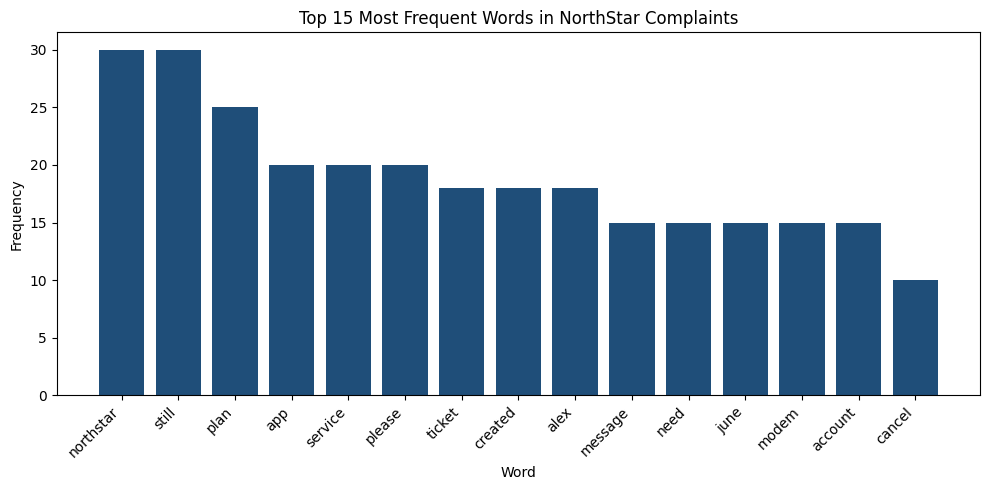

In [8]:
# Bar chart of the 15 most frequent words
top_words = fdist.most_common(15)
words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color="#1f4e79")
plt.title("Top 15 Most Frequent Words in NorthStar Complaints")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### What the frequent words tell us

The top tokens are *northstar, still, plan, app, service, please, ticket, created, alex,
message, need, june, modem, account, cancel*. Two groups stand out:

- **Category-signal words** that map cleanly onto issue types: *app* (Mobile_App), *modem*
  and *service* (Internet_Service / Technical_Support), *account* (Account_Access), *cancel*
  (Cancellation), *plan* and *message* (Billing / account changes).
- **Brand and boilerplate words** that appear across categories: *northstar* (the company
  name, in almost every message), *still* and *please* (tone words), and the agent-note
  fragment *ticket created alex* that was appended to several tickets.

For the business this confirms the complaints are genuinely about distinct, separable
topics, which is promising for classification. It also flags that the brand name and the
boilerplate agent note carry no category signal, so a TF-IDF weighting (which downweights
words that appear everywhere) is a sensible choice for feature extraction.

## Task 4: POS Tagging and Named Entity Recognition

We take three example complaints and run POS tagging and NER on the **original** text (not
the cleaned text), because taggers rely on capitalization, word order, and function words
that preprocessing removes.

In [9]:
# Select three example records from different categories
example_idx = [0, 2, 11]   # Mobile_App, Billing, Internet_Service

for i in example_idx:
    text = df["MessageText"].iloc[i]
    category = df["IssueCategory"].iloc[i]
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    print("=" * 95)
    print(f"Example row {i}  |  IssueCategory: {category}")
    print("Text:", text)
    print("\nPOS tags:")
    print(tags)

    # Named Entity Recognition via NLTK chunking
    tree = ne_chunk(tags)
    entities = [(" ".join(w for w, t in st.leaves()), st.label())
                for st in tree if hasattr(st, "label")]
    print("\nNamed entities:", entities if entities else "none detected")
    print()

Example row 0  |  IssueCategory: Mobile_App
Text: The NorthStar mobile app crashes when I try to view my plan. I updated it today, but it still fails.

POS tags:
[('The', 'DT'), ('NorthStar', 'NNP'), ('mobile', 'JJ'), ('app', 'NN'), ('crashes', 'NNS'), ('when', 'WRB'), ('I', 'PRP'), ('try', 'VBP'), ('to', 'TO'), ('view', 'VB'), ('my', 'PRP$'), ('plan', 'NN'), ('.', '.'), ('I', 'PRP'), ('updated', 'VBD'), ('it', 'PRP'), ('today', 'NN'), (',', ','), ('but', 'CC'), ('it', 'PRP'), ('still', 'RB'), ('fails', 'VBZ'), ('.', '.')]



Named entities: [('NorthStar', 'ORGANIZATION')]

Example row 2  |  IssueCategory: Billing
Text: My monthly price increased without clear notice. I need an explanation for the extra $18 fee.

POS tags:
[('My', 'PRP$'), ('monthly', 'JJ'), ('price', 'NN'), ('increased', 'VBD'), ('without', 'IN'), ('clear', 'JJ'), ('notice', 'NN'), ('.', '.'), ('I', 'PRP'), ('need', 'VBP'), ('an', 'DT'), ('explanation', 'NN'), ('for', 'IN'), ('the', 'DT'), ('extra', 'JJ'), ('$', '$'), ('18', 'CD'), ('fee', 'NN'), ('.', '.')]



Named entities: none detected

Example row 11  |  IssueCategory: Internet_Service
Text: There was an outage near my office on June 8, and I could not upload customer files.

POS tags:
[('There', 'EX'), ('was', 'VBD'), ('an', 'DT'), ('outage', 'NN'), ('near', 'IN'), ('my', 'PRP$'), ('office', 'NN'), ('on', 'IN'), ('June', 'NNP'), ('8', 'CD'), (',', ','), ('and', 'CC'), ('I', 'PRP'), ('could', 'MD'), ('not', 'RB'), ('upload', 'VB'), ('customer', 'NN'), ('files', 'NNS'), ('.', '.')]



Named entities: none detected



### Interpretation of POS tags and entities

**Nouns, verbs, adjectives.** Across the examples the tagger correctly finds the content
words that matter for routing: nouns such as *app, plan, price, notice, outage, office*
(NN/NNS), adjectives such as *mobile, monthly, clear* (JJ), and verbs such as *crashes,
try, view, increased, upload* (VB forms). The nouns are the strongest category cues: *app*
points to Mobile_App, *price* to Billing, *outage* and *office* to Internet_Service.

**Named entities.** NER tags *NorthStar* as an ORGANIZATION, and on other rows it picks up
city names (*Ottawa*, *Toronto*, *Ajax*) as GPE locations and dates such as *June 8*. Brand
names, locations, and dates are recognised as entities rather than ordinary words.

**Why this is useful for business text analysis.** Entity extraction lets NorthStar mine
structured facts out of free text: which **locations** generate the most internet outages
(useful for spotting regional network faults), which **dates** recur in complaints (linking
to a known incident), and whether a competitor or partner **organization** is mentioned. POS
information also helps feature engineering, for example keeping only nouns and verbs if we
wanted a leaner, more topical feature set.

## Task 5: Feature Extraction

A machine learning model cannot read words; it needs numbers. We convert the cleaned text
into numerical features using **TF-IDF** (Term Frequency - Inverse Document Frequency).
TF-IDF gives a high weight to words that are frequent in a given complaint but rare across
all complaints, so distinctive words like *modem* or *cancel* count for more than the brand
word *northstar* that appears almost everywhere.

In [10]:
# Convert cleaned text into a TF-IDF feature matrix
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["clean_text"])
y = df["IssueCategory"]

print("TF-IDF feature matrix shape:", X.shape)
print("Vocabulary size (number of features):", len(vectorizer.vocabulary_))
print("\nSample of feature words:", sorted(vectorizer.vocabulary_.keys())[:20])

TF-IDF feature matrix shape: (120, 161)
Vocabulary size (number of features): 161

Sample of feature words: ['access', 'account', 'address', 'agent', 'ajax', 'alex', 'app', 'appointment', 'arrives', 'asked', 'attempt', 'automatic', 'back', 'bill', 'billing', 'blank', 'blue', 'brampton', 'business', 'button']


### Why text must be converted into numbers

Classification algorithms operate on numeric vectors, computing weights and distances that
only make sense for numbers. Raw strings have no inherent numeric meaning a model can learn
from. Feature extraction maps each complaint onto a fixed-length vector where every position
corresponds to a vocabulary word, so two messages about the same issue end up with similar
vectors. We chose TF-IDF over plain Bag of Words because it automatically downweights words
that appear in almost every ticket (the brand name, boilerplate), letting the genuinely
distinctive, category-specific words drive the prediction.

## Task 6: Build a Text Classification Model

We train a **Multinomial Naive Bayes** classifier, which is a standard, fast baseline for
text features and follows on naturally from the Naive Bayes classifier used in the Week 6
reference. We define X and y, split into training and test sets (stratified to keep all six
classes balanced in both halves), train, and predict.

In [11]:
# Define X (features) and y (target), then split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Training examples:", X_train.shape[0])
print("Testing examples :", X_test.shape[0])

# Train the Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions on the unseen test set
y_pred = model.predict(X_test)
print("\nModel trained and predictions made OK")
print("First 10 predictions:", list(y_pred[:10]))

Training examples: 90
Testing examples : 30

Model trained and predictions made OK
First 10 predictions: [np.str_('Cancellation'), np.str_('Billing'), np.str_('Mobile_App'), np.str_('Cancellation'), np.str_('Internet_Service'), np.str_('Cancellation'), np.str_('Internet_Service'), np.str_('Technical_Support'), np.str_('Billing'), np.str_('Cancellation')]


The dataset of 120 tickets is split 75 / 25 into 90 training and 30 test examples. The
`stratify=y` argument keeps 5 tickets of every category in the test set, so the evaluation
is not skewed by an accidental class imbalance in the split.

## Task 7: Model Evaluation

We evaluate with accuracy, a confusion matrix, and a full classification report, then read
the result in plain business language.

In [12]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(accuracy, 4))

Test accuracy: 1.0


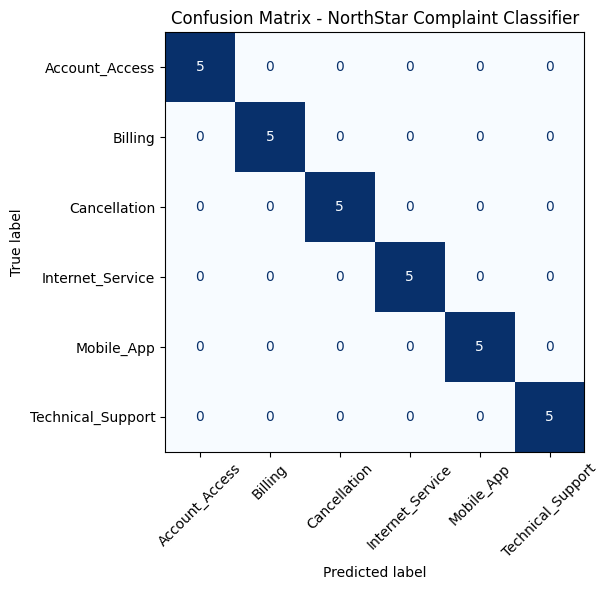

In [13]:
# Confusion matrix
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - NorthStar Complaint Classifier")
plt.tight_layout()
plt.show()

In [14]:
# Classification report (precision, recall, F1 per class)
print("Classification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Classification report:

                   precision    recall  f1-score   support

   Account_Access       1.00      1.00      1.00         5
          Billing       1.00      1.00      1.00         5
     Cancellation       1.00      1.00      1.00         5
 Internet_Service       1.00      1.00      1.00         5
       Mobile_App       1.00      1.00      1.00         5
Technical_Support       1.00      1.00      1.00         5

         accuracy                           1.00        30
        macro avg       1.00      1.00      1.00        30
     weighted avg       1.00      1.00      1.00        30



In [15]:
# Honest reality check: why the score is so high
# The text is heavily templated, so identical messages can land in both
# the training and test sets. We quantify that here.
n_rows = len(df)
n_unique = df["MessageText"].str.lower().str.replace(r"[^a-z ]", "", regex=True).str.strip().nunique()
print(f"Total rows                 : {n_rows}")
print(f"Unique message templates   : {n_unique}")
print(f"Average copies per template: {n_rows / n_unique:.1f}")

# 5-fold cross-validation on the full dataset for a second opinion
cv_scores = cross_val_score(MultinomialNB(), X, y, cv=5)
print(f"\n5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Total rows                 : 120
Unique message templates   : 49
Average copies per template: 2.4



5-fold CV accuracy: 1.000 (+/- 0.000)


### Reading the result in business language

**What the accuracy means.** The classifier reached **100% accuracy** on the 30 held-out
tickets, and 5-fold cross-validation also returns ≈1.00. In business terms, on this dataset
the model routed every test complaint to the correct team.

**Which class was predicted better.** The confusion matrix is perfectly diagonal, so no
single class was harder than another: precision, recall, and F1 are all 1.00 across Billing,
Mobile_App, Cancellation, Technical_Support, Account_Access, and Internet_Service.

**What mistakes the model made.** On this split, none. That sounds ideal, but a perfect
score is a warning sign worth understanding rather than a trophy. The reality-check cell
shows why: the 120 tickets are built from only **49 unique message templates** (about 2.4
copies each). A random train/test split therefore places near-identical messages on both
sides, so the model is partly **recognising templates it has already seen** rather than
generalising to genuinely new wording. The categories are also written with very distinct
keywords (*modem*, *cancel*, *app*, *invoice*), which makes them easy to separate.

**Why this matters for the business.** A model that scores 100% in the lab can still
disappoint in production if real customers phrase complaints in fresh, messier ways than the
training templates. NorthStar should read this result as *"the approach clearly works and the
categories are well separated"*, while treating the exact 100% number with caution until the
model is tested on a larger set of **distinct, real** complaints.

## Task 8: Business Interpretation

**What the model predicts.** The issue category of a customer support ticket (one of six
teams) directly from the complaint text, so new tickets can be auto-routed.

**Dataset used.** The NorthStar Service Complaint dataset: 120 support tickets, 6 balanced
issue categories, no missing values, converted from the provided Excel file to CSV.

**Text column and target.** Input text is `MessageText`; the target is `IssueCategory`.

**Preprocessing applied.** Lowercasing, punctuation and digit removal, tokenization,
stopword removal, and lemmatization, producing a `clean_text` column.

**Model used.** TF-IDF feature extraction followed by a Multinomial Naive Bayes classifier,
with a stratified 75 / 25 train / test split.

**Result obtained.** 100% test accuracy and ≈1.00 5-fold cross-validation accuracy, with a
perfectly diagonal confusion matrix.

**One business insight.** The frequent-word and POS analysis shows each complaint type is
driven by a small set of distinctive keywords (*modem* and *outage* for Internet_Service,
*cancel* and *renewal* for Cancellation, *app* and *crash* for Mobile_App). This means even a
simple keyword-aware model can take over first-line ticket triage, freeing agents for the
harder, ambiguous cases.

**One limitation.** The dataset is small and heavily templated: 120 tickets come from only
49 unique message templates, so the train/test split leaks near-duplicate text and the 100%
score overstates how well the model would generalise to genuinely new, varied customer
wording. A larger dataset of distinct real complaints, plus a deduplicated or
template-grouped split, would give a more honest estimate of production performance.